# MedGemma Tissue Classification Validation

Compare MedGemma's tissue involvement statistics (extracted from HTML reports) against ClinVar `cardiac` / `muscular` ground truth labels.

**Pipeline**
1. Parse HTML reports → MedGemma tissue counts per variant
2. Build ClinVar lookup (merge `clinvar_latest.csv` + `clinvar_result_with_ref_alt.csv`)
3. Fill remaining gaps via NCBI eutils API
4. Compute dominant phenotype + agreement metrics
5. Visualise: confusion matrix, scatter, extraction quality

In [1]:
from pathlib import Path
import re, time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import urllib.request, urllib.parse, json
from bs4 import BeautifulSoup

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

OUTPUTS_DIR  = Path('/home/ryan910702/ttn-agent/outputs')
CLINVAR_LATEST   = Path('/home/ryan910702/ttn-agent/data/clinvar_latest.csv')
CLINVAR_REF_ALT  = Path('/home/ryan910702/ttn-agent/data/clinvar_result_with_ref_alt.csv')

CARDIAC_KW  = ['cardiomyopathy','cardiovascular','heart','cardiac']
MUSCULAR_KW = ['myofibrillar','Early-onset myopathy',
              'muscle','amyotrophy','muscular']
SKIP_TERMS  = {'not provided','not specified','see cases',''}

## Step 1 — Parse HTML Reports → MedGemma Tissue Counts

In [2]:
def parse_html_report(html_path: Path) -> dict:
    with open(html_path, encoding='utf-8') as f:
        soup = BeautifulSoup(f, 'html.parser')

    title = soup.title.string if soup.title else ''
    m = re.search(r'(\d+-\d+-[A-Z]+-[A-Z]+)', title)
    variant_id = m.group(1) if m else None

    lines = [l.strip() for l in soup.get_text().split('\n') if l.strip()]

    def extract_count(label):
        for i, line in enumerate(lines):
            if line == label and i + 1 < len(lines):
                nm = re.match(r'(\d+)\s+article', lines[i + 1])
                if nm:
                    return int(nm.group(1))
        return None

    total_articles = None
    for line in lines:
        tm = re.search(r'Literature Review \((\d+) articles\)', line)
        if tm:
            total_articles = int(tm.group(1))
            break

    return {
        'variant_id':     variant_id,
        'total_articles': total_articles,
        'mg_cardiac':     extract_count('Cardiac'),
        'mg_skeletal':    extract_count('Skeletal'),
        'mg_both':        extract_count('Both'),
        'mg_not_spec':    extract_count('Not Specified'),
        'html_file':      html_path.name,
    }


raw = [parse_html_report(p) for p in sorted(OUTPUTS_DIR.glob('*.html'))]
raw = [r for r in raw if r['variant_id'] and r['mg_cardiac'] is not None]

# For duplicates keep the run with most articles (most complete)
mg_df = (
    pd.DataFrame(raw)
    .sort_values('total_articles', ascending=False)
    .drop_duplicates('variant_id', keep='first')
    .reset_index(drop=True)
)

print(f'Unique variants with HTML reports: {len(mg_df)}')
mg_df[['variant_id','total_articles','mg_cardiac','mg_skeletal','mg_both','mg_not_spec']]

Unique variants with HTML reports: 213


,variant_id,total_articles,mg_cardiac,mg_skeletal,mg_both,mg_not_spec
0,2-178546102-T-C,31,6,11,4,10
1,2-178799566-C-T,28,8,6,1,13
2,2-178546041-C-T,28,6,18,1,3
3,2-178782980-T-C,23,18,0,0,5
4,2-178534401-T-C,22,9,4,1,8
...,...,...,...,...,...,...
208,2-178530455-C-G,1,0,0,0,1
209,2-178530118-A-G,1,0,0,0,1
210,2-178527108-C-T,1,0,0,0,1
211,2-178527264-T-C,1,0,0,0,1


## Step 2 — Build ClinVar Ground-Truth Lookup

Merge both local ClinVar CSVs (they cover different variant sets).

In [3]:
def build_variant_id(df):
    return (df['chr'].astype(str) + '-' +
            df['position'].astype(str) + '-' +
            df['ref'].astype(str) + '-' +
            df['alt'].astype(str))

keep_cols = ['variant_id', 'cardiac', 'muscular', 'Germline classification', 'Condition(s)']

df_latest  = pd.read_csv(CLINVAR_LATEST)
df_refalt  = pd.read_csv(CLINVAR_REF_ALT)

df_latest['variant_id'] = build_variant_id(df_latest)
df_refalt['variant_id'] = build_variant_id(df_refalt)

# Rename ground trruth -> Germline classification in refalt if needed
if 'Germline classification' not in df_refalt.columns and 'ground trruth' in df_refalt.columns:
    df_refalt = df_refalt.rename(columns={'ground trruth': 'Germline classification'})

combined = pd.concat([
    df_latest[keep_cols],
    df_refalt[keep_cols]
]).drop_duplicates('variant_id', keep='first')

clinvar_lookup = combined.set_index('variant_id')

# Coverage check
all_ids = set(mg_df['variant_id'])
matched = all_ids & set(clinvar_lookup.index)
missing_ids = all_ids - matched
print(f'Variants in HTML reports  : {len(all_ids)}')
print(f'Matched in local ClinVar  : {len(matched)} → {sorted(matched)}')
print(f'Need API lookup           : {len(missing_ids)} → {sorted(missing_ids)}')

Variants in HTML reports  : 213
Matched in local ClinVar  : 208 → ['2-178526348-G-T', '2-178527108-C-T', '2-178527121-T-C', '2-178527148-T-A', '2-178527264-T-C', '2-178527288-A-G', '2-178527300-G-A', '2-178527353-T-A', '2-178527491-C-T', '2-178527548-C-T', '2-178528273-G-A', '2-178528273-G-C', '2-178528300-C-G', '2-178528367-C-T', '2-178528428-G-C', '2-178528797-C-T', '2-178528798-C-G', '2-178529959-G-A', '2-178530118-A-G', '2-178530336-C-T', '2-178530426-C-T', '2-178530455-C-G', '2-178530861-C-T', '2-178531192-C-G', '2-178531668-C-T', '2-178531674-G-T', '2-178531788-C-T', '2-178531844-C-A', '2-178531862-T-A', '2-178531962-C-T', '2-178532100-C-T', '2-178532202-C-T', '2-178532523-C-T', '2-178532670-C-T', '2-178532770-C-G', '2-178532811-C-T', '2-178532844-C-T', '2-178532910-A-T', '2-178533241-C-A', '2-178534030-T-A', '2-178534092-C-T', '2-178534263-C-T', '2-178534401-T-C', '2-178534619-G-A', '2-178534662-G-T', '2-178534672-C-G', '2-178534887-G-T', '2-178534928-C-A', '2-178534973-C-G', '2

## Step 3 — Fill Gaps via NCBI ClinVar API

For variants not in the local CSV, query NCBI eutils to get their `Condition(s)` and compute `cardiac` / `muscular` counts.

In [4]:
def count_labels_from_conditions(conditions_str: str):
    """Apply cardiac/muscular keyword classification to a pipe-separated conditions string."""
    if not conditions_str or pd.isna(conditions_str):
        return 0, 0
    seen, cardiac_n, muscular_n = set(), 0, 0
    for term in conditions_str.split('|'):
        t = term.strip()
        if t in seen or t.lower() in SKIP_TERMS:
            continue
        seen.add(t)
        c = t.lower()
        cardiac_n  += any(k in c for k in CARDIAC_KW)
        muscular_n += any(k in c for k in MUSCULAR_KW)
    return cardiac_n, muscular_n


COMP_TABLE = str.maketrans('ACGTacgt', 'TGCAtgca')

def _complement(base: str) -> str:
    """Complement a nucleotide (TTN is on minus strand, so ClinVar stores complement)."""
    return base.translate(COMP_TABLE)


def fetch_clinvar_conditions(chrom, pos, ref, alt):
    """
    Query NCBI ClinVar eutils for a TTN variant.
    TTN is on the minus strand, so SPDI uses complement of ref/alt.
    Returns (conditions_str, germline_classification) or (None, None).
    """
    spdi = f'NC_000002.12:{int(pos)-1}:{_complement(ref)}:{_complement(alt)}'
    url = ('https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi'
           f'?db=clinvar&term={urllib.parse.quote(spdi)}&retmode=json')
    try:
        with urllib.request.urlopen(url, timeout=10) as resp:
            data = json.loads(resp.read())
        ids = data.get('esearchresult', {}).get('idlist', [])
        if not ids:
            return None, None

        uid = ids[0]
        sum_url = (f'https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esummary.fcgi'
                   f'?db=clinvar&id={uid}&retmode=json')
        time.sleep(0.35)  # NCBI rate limit: 3 req/s
        with urllib.request.urlopen(sum_url, timeout=10) as resp:
            sdata = json.loads(resp.read())

        doc = sdata.get('result', {}).get(uid, {})
        germline_block = doc.get('germline_classification', {})
        germline = germline_block.get('description', '')

        # Conditions are under germline_classification.trait_set
        trait_set = germline_block.get('trait_set', [])
        cond_names = [t.get('trait_name', '') for t in trait_set if t.get('trait_name')]
        conditions = '|'.join(cond_names) if cond_names else None
        return conditions, germline

    except Exception as e:
        print(f'  API error for {chrom}-{pos}-{ref}-{alt}: {e}')
        return None, None


api_rows = []
for vid in sorted(missing_ids):
    parts = vid.split('-')
    chrom, pos, ref, alt = parts[0], parts[1], parts[2], parts[3]
    print(f'Querying API: {vid} ...', end=' ')
    conditions, germline = fetch_clinvar_conditions(chrom, pos, ref, alt)
    if conditions:
        cardiac_n, muscular_n = count_labels_from_conditions(conditions)
        print(f'cardiac={cardiac_n}, muscular={muscular_n}  [{germline}]')
    else:
        cardiac_n, muscular_n = 0, 0
        print('not found in ClinVar')
    api_rows.append({
        'variant_id': vid,
        'cardiac': cardiac_n,
        'muscular': muscular_n,
        'Germline classification': germline or 'Unknown',
        'Condition(s)': conditions or 'not provided',
    })
    time.sleep(0.35)

if api_rows:
    api_df = pd.DataFrame(api_rows).set_index('variant_id')
    clinvar_lookup = pd.concat([clinvar_lookup, api_df])

print(f'\nTotal ClinVar lookup entries: {len(clinvar_lookup)}')

Querying API: 2-178527200-T-C ... cardiac=1, muscular=1  [Uncertain significance]
Querying API: 2-178530461-A-C ... cardiac=3, muscular=3  [Uncertain significance]
Querying API: 2-178621119-C-G ... cardiac=4, muscular=3  [Conflicting classifications of pathogenicity]
Querying API: 2-178768672-G-C ... cardiac=2, muscular=1  [Conflicting classifications of pathogenicity]
Querying API: 2-178799566-C-T ... cardiac=4, muscular=3  [Conflicting classifications of pathogenicity]

Total ClinVar lookup entries: 7185


## Step 4 — Merge & Compute Dominant Phenotype

In [5]:
df = mg_df.join(clinvar_lookup, on='variant_id')

still_missing = df['cardiac'].isna().sum()
if still_missing:
    print(f'Warning: {still_missing} variant(s) still have no ClinVar data — excluded')
    print(df[df['cardiac'].isna()]['variant_id'].tolist())

df = df.dropna(subset=['cardiac', 'muscular']).copy()
df['cardiac']  = df['cardiac'].astype(int)
df['muscular'] = df['muscular'].astype(int)


def dominant(a, b):
    if a > b: return 'cardiac'
    if b > a: return 'muscular'
    return 'mixed'


df['cv_dominant'] = df.apply(lambda r: dominant(r['cardiac'],    r['muscular']),    axis=1)
df['mg_dominant'] = df.apply(lambda r: dominant(r['mg_cardiac'], r['mg_skeletal']), axis=1)
df['agree']       = df['cv_dominant'] == df['mg_dominant']

cols = ['variant_id', 'cardiac', 'muscular', 'cv_dominant',
        'mg_cardiac', 'mg_skeletal', 'mg_both', 'mg_not_spec', 'mg_dominant', 'agree']
display(df[cols].reset_index(drop=True))
print(f'\nOverall agreement: {df["agree"].sum()}/{len(df)} = {df["agree"].mean():.1%}')

,variant_id,cardiac,muscular,cv_dominant,mg_cardiac,mg_skeletal,mg_both,mg_not_spec,mg_dominant,agree
0,2-178546102-T-C,5,7,muscular,6,11,4,10,muscular,True
1,2-178799566-C-T,4,3,cardiac,8,6,1,13,cardiac,True
2,2-178546041-C-T,5,8,muscular,6,18,1,3,muscular,True
3,2-178782980-T-C,1,1,mixed,18,0,0,5,cardiac,False
4,2-178534401-T-C,2,2,mixed,9,4,1,8,cardiac,False
...,...,...,...,...,...,...,...,...,...,...
208,2-178530455-C-G,1,1,mixed,0,0,0,1,mixed,True
209,2-178530118-A-G,1,1,mixed,0,0,0,1,mixed,True
210,2-178527108-C-T,2,3,muscular,0,0,0,1,mixed,False
211,2-178527264-T-C,2,3,muscular,0,0,0,1,mixed,False



Overall agreement: 58/213 = 27.2%


## Step 5 — Agreement Table & Confusion Matrix

In [6]:
# Pretty agreement table
summary = df[cols + ['Germline classification', 'Condition(s)']].copy()
summary['agree'] = summary['agree'].map({True: '✓', False: '✗'})
display(summary.reset_index(drop=True))
print(f'Agreement rate: {(summary["agree"] == "✓").mean():.1%}')

,variant_id,cardiac,muscular,cv_dominant,mg_cardiac,mg_skeletal,mg_both,mg_not_spec,mg_dominant,agree,Germline classification,Condition(s)
0,2-178546102-T-C,5,7,muscular,6,11,4,10,muscular,✓,Pathogenic/Likely pathogenic,Cardiovascular phenotype|Autosomal recessive l...
1,2-178799566-C-T,4,3,cardiac,8,6,1,13,cardiac,✓,Conflicting classifications of pathogenicity,Cardiovascular phenotype|Dilated cardiomyopath...
2,2-178546041-C-T,5,8,muscular,6,18,1,3,muscular,✓,Pathogenic/Likely pathogenic,Hereditary inclusion-body myopathy|Autosomal r...
3,2-178782980-T-C,1,1,mixed,18,0,0,5,cardiac,✗,Likely pathogenic,Primary dilated cardiomyopathy
4,2-178534401-T-C,2,2,mixed,9,4,1,8,cardiac,✗,Pathogenic/Likely pathogenic,Cardiovascular phenotype|Autosomal recessive l...
...,...,...,...,...,...,...,...,...,...,...,...,...
208,2-178530455-C-G,1,1,mixed,0,0,0,1,mixed,✓,Pathogenic,Dilated cardiomyopathy 1G|not provided
209,2-178530118-A-G,1,1,mixed,0,0,0,1,mixed,✓,Pathogenic/Likely pathogenic,Dilated cardiomyopathy 1G|not provided
210,2-178527108-C-T,2,3,muscular,0,0,0,1,mixed,✗,Likely benign,Cardiomyopathy|Dilated cardiomyopathy 1G|Autos...
211,2-178527264-T-C,2,3,muscular,0,0,0,1,mixed,✗,Likely benign,Cardiomyopathy|Dilated cardiomyopathy 1G|Autos...


Agreement rate: 27.2%


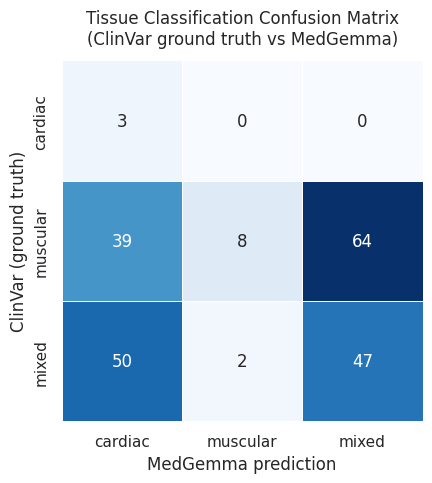

MedGemma prediction     cardiac  muscular  mixed
ClinVar (ground truth)                          
cardiac                       3         0      0
muscular                     39         8     64
mixed                        50         2     47


In [7]:
categories = ['cardiac', 'muscular', 'mixed']
cm_data = pd.crosstab(
    df['cv_dominant'],
    df['mg_dominant'],
    rownames=['ClinVar (ground truth)'],
    colnames=['MedGemma prediction'],
).reindex(index=categories, columns=categories, fill_value=0)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, square=True, cbar=False, ax=ax)
ax.set_title('Tissue Classification Confusion Matrix\n(ClinVar ground truth vs MedGemma)', pad=12)
plt.tight_layout()
plt.show()

print(cm_data)

## Step 6 — Cardiac Fraction Scatter

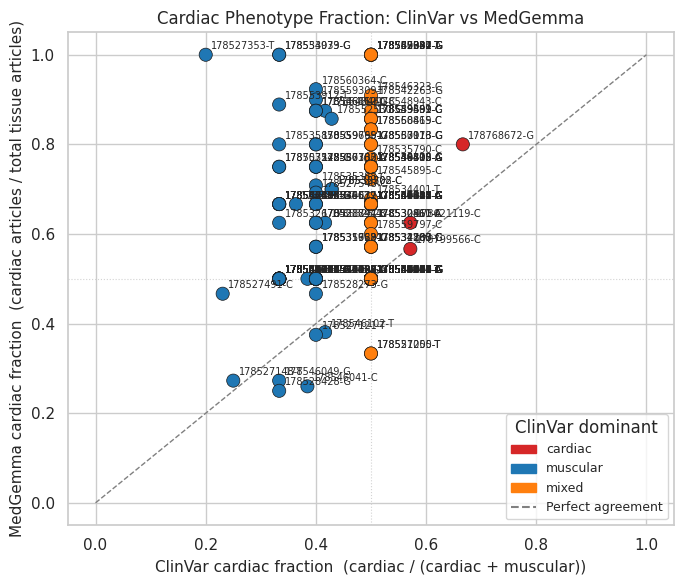

In [8]:
denom_cv = (df['cardiac'] + df['muscular']).replace(0, np.nan)
df['cv_cardiac_frac'] = df['cardiac'] / denom_cv

# 'Both' articles contribute 0.5 to each side
denom_mg = (df['mg_cardiac'] + df['mg_skeletal'] + df['mg_both']).replace(0, np.nan)
df['mg_cardiac_frac'] = (df['mg_cardiac'] + 0.5 * df['mg_both']) / denom_mg

plot_df = df.dropna(subset=['cv_cardiac_frac', 'mg_cardiac_frac']).copy()

color_map = {'cardiac': '#d62728', 'muscular': '#1f77b4', 'mixed': '#ff7f0e'}
colors = plot_df['cv_dominant'].map(color_map)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(plot_df['cv_cardiac_frac'], plot_df['mg_cardiac_frac'],
           c=colors, s=90, edgecolors='k', linewidths=0.5, zorder=3)
ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=1)
ax.axhline(0.5, color='lightgray', linewidth=0.8, linestyle=':')
ax.axvline(0.5, color='lightgray', linewidth=0.8, linestyle=':')

for _, row in plot_df.iterrows():
    label = '-'.join(row['variant_id'].split('-')[1:3])   # e.g. 178527121-T
    ax.annotate(label, (row['cv_cardiac_frac'], row['mg_cardiac_frac']),
                fontsize=7, xytext=(4, 4), textcoords='offset points')

handles = [mpatches.Patch(color=c, label=l) for l, c in color_map.items()]
handles.append(plt.Line2D([0], [0], linestyle='--', color='gray', label='Perfect agreement'))
ax.legend(handles=handles, title='ClinVar dominant', fontsize=9)
ax.set_xlabel('ClinVar cardiac fraction  (cardiac / (cardiac + muscular))', fontsize=11)
ax.set_ylabel('MedGemma cardiac fraction  (cardiac articles / total tissue articles)', fontsize=11)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.set_title('Cardiac Phenotype Fraction: ClinVar vs MedGemma', fontsize=12)
plt.tight_layout()
plt.show()

## Step 7 — Extraction Quality (Not-Specified Rate)

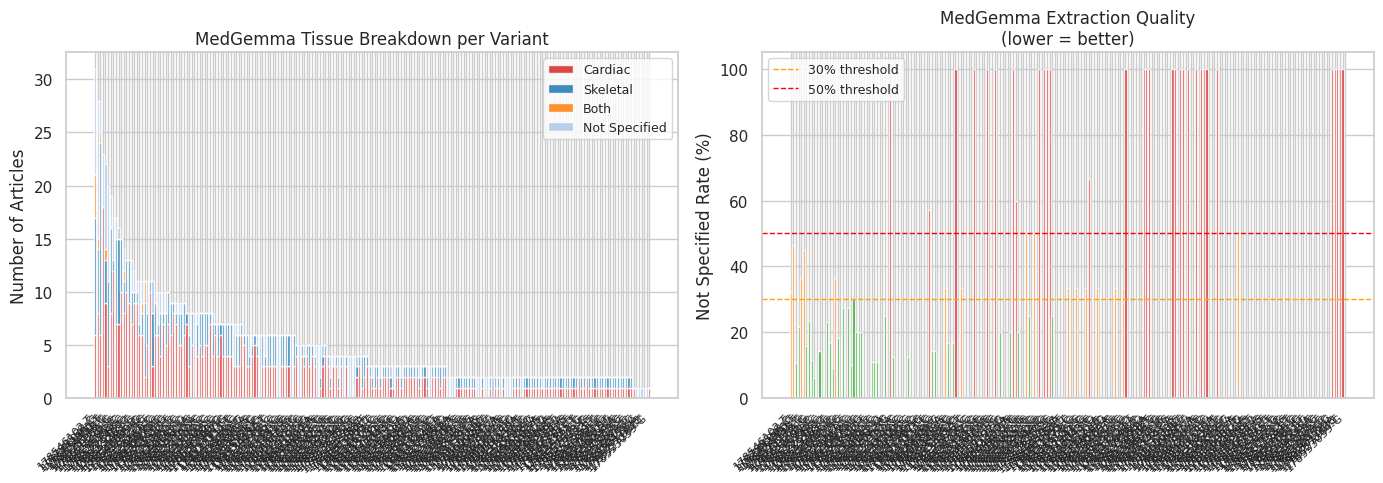

Mean not-specified rate: 20.1%
Max not-specified rate:  100.0%


In [9]:
df['mg_not_spec_rate'] = df['mg_not_spec'] / df['total_articles'].replace(0, np.nan)
short_labels = ['-'.join(v.split('-')[1:3]) for v in df['variant_id']]
x = range(len(df))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar — tissue breakdown
axes[0].bar(x, df['mg_cardiac'],  label='Cardiac',       color='#d62728', alpha=0.85)
axes[0].bar(x, df['mg_skeletal'], label='Skeletal',      color='#1f77b4', alpha=0.85,
            bottom=df['mg_cardiac'])
axes[0].bar(x, df['mg_both'],     label='Both',          color='#ff7f0e', alpha=0.85,
            bottom=df['mg_cardiac'] + df['mg_skeletal'])
axes[0].bar(x, df['mg_not_spec'], label='Not Specified', color='#aec7e8', alpha=0.85,
            bottom=df['mg_cardiac'] + df['mg_skeletal'] + df['mg_both'])
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Number of Articles')
axes[0].set_title('MedGemma Tissue Breakdown per Variant')
axes[0].legend(fontsize=9)

# Not-specified rate
bar_colors = ['#2ca02c' if r <= 0.3 else '#ff7f0e' if r <= 0.5 else '#d62728'
              for r in df['mg_not_spec_rate'].fillna(0)]
axes[1].bar(x, df['mg_not_spec_rate'].fillna(0) * 100, color=bar_colors, alpha=0.85)
axes[1].axhline(30, color='orange', linestyle='--', linewidth=1, label='30% threshold')
axes[1].axhline(50, color='red',    linestyle='--', linewidth=1, label='50% threshold')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(short_labels, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Not Specified Rate (%)')
axes[1].set_title('MedGemma Extraction Quality\n(lower = better)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Mean not-specified rate: {df["mg_not_spec_rate"].mean():.1%}')
print(f'Max not-specified rate:  {df["mg_not_spec_rate"].max():.1%}')

## Step 8 — Disagreement Deep-Dive

In [10]:
disagree = df[~df['agree']].copy()

if len(disagree) == 0:
    print('All variants agree!')
else:
    print(f'{len(disagree)} disagreement(s):\n')
    for _, row in disagree.iterrows():
        print(f"Variant : {row['variant_id']}")
        print(f"  ClinVar   cardiac={row['cardiac']}, muscular={row['muscular']}"
              f" → dominant={row['cv_dominant']}")
        print(f"  MedGemma  cardiac={row['mg_cardiac']}, skeletal={row['mg_skeletal']},"
              f" both={row['mg_both']}, not_spec={row['mg_not_spec']}"
              f" → dominant={row['mg_dominant']}")
        print(f"  Conditions : {str(row['Condition(s)'])[:150]}")
        print(f"  Germline   : {row['Germline classification']}")
        print()

155 disagreement(s):

Variant : 2-178782980-T-C
  ClinVar   cardiac=1, muscular=1 → dominant=mixed
  MedGemma  cardiac=18, skeletal=0, both=0, not_spec=5 → dominant=cardiac
  Conditions : Primary dilated cardiomyopathy
  Germline   : Likely pathogenic

Variant : 2-178534401-T-C
  ClinVar   cardiac=2, muscular=2 → dominant=mixed
  MedGemma  cardiac=9, skeletal=4, both=1, not_spec=8 → dominant=cardiac
  Conditions : Cardiovascular phenotype|Autosomal recessive limb-girdle muscular dystrophy type 2J|Dilated cardiomyopathy 1G|not provided|Autosomal recessive limb-gi
  Germline   : Pathogenic/Likely pathogenic

Variant : 2-178528273-G-A
  ClinVar   cardiac=5, muscular=8 → dominant=muscular
  MedGemma  cardiac=8, skeletal=8, both=0, not_spec=3 → dominant=mixed
  Conditions : Cardiovascular phenotype|Autosomal recessive limb-girdle muscular dystrophy type 2J|Dilated cardiomyopathy 1G|Neuromuscular disease|Autosomal recessiv
  Germline   : Pathogenic/Likely pathogenic

Variant : 2-178560364-C-